In [2]:
!pip install "numpy==2.0.2" pennylane


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
"""
evaluation_schemes.py  (inlined so Kaggle needs no external file)
"""

import numpy as np
from sklearn.metrics import f1_score, hamming_loss, classification_report


def exact_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    assert gold.shape == preds.shape, "gold and preds must have the same shape"
    row_matches = np.all(gold == preds, axis=1)
    emr = float(row_matches.mean())
    return {"precision": emr, "recall": emr, "f1": emr,
            "exact_match_ratio": emr, "num_exact_matches": int(row_matches.sum())}


def _instance_prf(gold_row: np.ndarray, pred_row: np.ndarray):
    gold_set = set(np.where(gold_row == 1)[0])
    pred_set = set(np.where(pred_row == 1)[0])
    if len(gold_set) == 0 and len(pred_set) == 0:
        return 1.0, 1.0, 1.0
    if len(gold_set) == 0 or len(pred_set) == 0:
        return 0.0, 0.0, 0.0
    overlap = len(gold_set & pred_set)
    precision = overlap / len(pred_set)
    recall = overlap / len(gold_set)
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    return precision, recall, f1


def partial_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    assert gold.shape == preds.shape
    precisions, recalls, f1s = [], [], []
    for g_row, p_row in zip(gold, preds):
        p, r, f = _instance_prf(g_row, p_row)
        precisions.append(p); recalls.append(r); f1s.append(f)
    return {"precision": float(np.mean(precisions)),
            "recall": float(np.mean(recalls)),
            "f1": float(np.mean(f1s))}


def evaluate_all_schemes(gold, preds, label_names=None, verbose=False):
    scheme1 = {
        "macro_f1": f1_score(gold, preds, average="macro", zero_division=0),
        "micro_f1": f1_score(gold, preds, average="micro", zero_division=0),
        "weighted_f1": f1_score(gold, preds, average="weighted", zero_division=0),
        "hamming_loss": hamming_loss(gold, preds),
    }
    scheme2 = exact_match_scores(gold, preds)
    scheme3 = partial_match_scores(gold, preds)
    return {"scheme1": scheme1, "scheme2": scheme2, "scheme3": scheme3}


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, hamming_loss
)
from sklearn.utils.class_weight import compute_class_weight

from tqdm import tqdm
import pennylane as qml

try:
    from evaluation_schemes import evaluate_all_schemes
except ModuleNotFoundError:
    pass  # defined in the inlined cell above



/home/itsmaestro/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'evaluation_schemes'

In [3]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

print("GPU device:", gpu_device)
print("CPU device:", cpu_device)

GPU device: cuda
CPU device: cpu


In [4]:
def set_seed(seed_value=42):
    """Set seeds for reproducibility across PyTorch, NumPy, and Python."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [5]:
df_tr = pd.read_csv('../emonoba_dataset/Train.csv')
df_vl = pd.read_csv('../emonoba_dataset/Val.csv')
df_te = pd.read_csv('../emonoba_dataset/Test.csv')

# Reset indices for safe iloc access in Dataset
df_tr = df_tr.reset_index(drop=True)
df_vl = df_vl.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

print("Train:", df_tr.shape, "| Valid:", df_vl.shape, "| Test:", df_te.shape)
df_tr.head()

Train: (18420, 11) | Valid: (2047, 11) | Test: (2272, 11)


,ID,Data,Love,Joy,Surprise,Anger,Sadness,Fear,Topic,Domain,is_admin
0,5454,লকাল বাস ভালো এটা থেকে,0,0,0,0,1,0,Travel,Youtube,False
1,22549,কত অভিজানই তো চলে কিন্তু ওয়াসার পানির অভিজান ক...,0,0,0,0,1,0,Politics,Youtube,False
2,7033,বিয়ের মহল ছেড়ে তিনি বিস্রাম নিতে চলে যান (৬ ...,0,0,0,1,0,0,Personal,Facebook,False
3,21114,চাচাজি তো কেবল মাকে ধর্ষণ করেছেন,0,0,0,0,1,0,Education,Facebook,False
4,23683,সত্যিকার মানুষ তারাই ভাই,0,1,0,0,0,0,Personal,Youtube,False


In [6]:
EMOTION_COLS = ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']
TEXT_COL     = 'Data'
NUM_LABELS   = len(EMOTION_COLS)

for split_name, split_df in [('Train', df_tr), ('Valid', df_vl), ('Test', df_te)]:
    assert TEXT_COL in split_df.columns, f"{split_name}: missing column '{TEXT_COL}'"
    assert all(c in split_df.columns for c in EMOTION_COLS), \
        f"{split_name}: missing emotion columns"

print(f"NUM_LABELS = {NUM_LABELS}  →  {EMOTION_COLS}")
print("\nTrain label distribution:")
print(df_tr[EMOTION_COLS].sum().sort_values(ascending=False))

NUM_LABELS = 6  →  ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']

Train label distribution:
Joy         8314
Sadness     4569
Love        3786
Anger       3542
Surprise     848
Fear         279
dtype: int64


In [7]:
class EmoNoBaDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        encoding = self.tokenizer(
            str(row[TEXT_COL]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        label = torch.tensor(
            row[EMOTION_COLS].values.astype(np.float32),
            dtype=torch.float32
        )

        return (
            encoding['input_ids'].squeeze(0),       # (max_length,)
            encoding['attention_mask'].squeeze(0),  # (max_length,)
            label                                   # (NUM_LABELS,)
        )

In [8]:
TEXT_MODEL   = 'csebuetnlp/banglabert'

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).to(gpu_device)

print("Text encoder loaded on:", next(text_encoder.parameters()).device)

Text encoder loaded on: cuda:0


0: ──RX(0.00)─╭StronglyEntanglingLayers(M0)─┤  <Z>
1: ──RX(0.00)─├StronglyEntanglingLayers(M0)─┤  <Z>
2: ──RX(0.00)─├StronglyEntanglingLayers(M0)─┤  <Z>
3: ──RX(0.00)─╰StronglyEntanglingLayers(M0)─┤  <Z>

M0 = 
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])


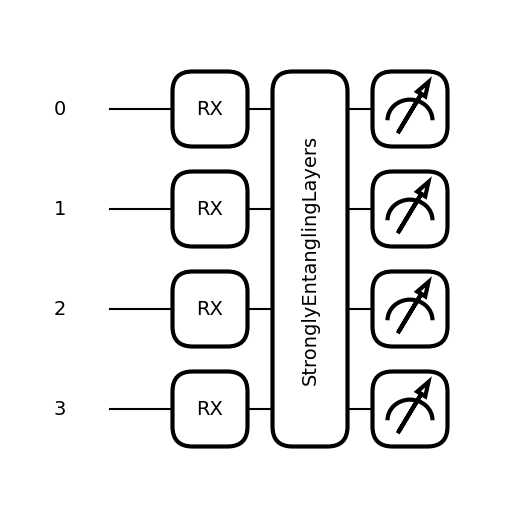

In [4]:
N_QUBITS   = 4
N_Q_LAYERS = 1

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch', diff_method='backprop')
def quantum_circuit(inputs, weights):
    # ── Data Encoding: RX rotation per qubit ──────────────────────────────────
    for i in range(N_QUBITS):
        qml.RX(inputs[i], wires=i)

    # ── Variational Block: StronglyEntanglingLayers ───────────────────────────
    # Each layer applies Rot(φ,θ,ω) on every qubit + CNOT entangling
    # with controllable range. Weight shape: (n_layers, n_qubits, 3)
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))

    # ── Measurement: PauliZ expectation on every qubit ────────────────────────
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


# Preview the circuit
dummy_inputs  = torch.zeros(N_QUBITS)
dummy_weights = torch.zeros(N_Q_LAYERS, N_QUBITS, 3)   # ← 3 angles per qubit
print(qml.draw(quantum_circuit)(dummy_inputs, dummy_weights))
# Draw the circuit with matplotlib and display it
fig, ax = qml.draw_mpl(quantum_circuit)(dummy_inputs, dummy_weights)
plt.show()


In [10]:
class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        # StronglyEntanglingLayers weight shape: (n_layers, n_qubits, 3)
        self.weights = nn.Parameter(
            torch.randn(N_Q_LAYERS, N_QUBITS, 3)   # ← was (N_Q_LAYERS, N_QUBITS)
        )

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = torch.stack(quantum_circuit(x[i], self.weights))
            outputs.append(out)
        return torch.stack(outputs)

In [11]:
class QuantumFusionLayer(nn.Module):
    def __init__(self, in_dim=128, q_dim=4):
        super().__init__()
        assert q_dim == N_QUBITS, "q_dim must match N_QUBITS"

        self.pre_q   = nn.Linear(in_dim, q_dim)
        self.quantum = QuantumBottleneck()
        self.post_q  = nn.Linear(q_dim, in_dim)

    def forward(self, x):

        x_q = torch.tanh(self.pre_q(x))
        
        q_out = self.quantum(x_q.to(cpu_device))

        q_out = q_out.to(x.device).float()

        return self.post_q(q_out)                     

In [12]:
class QuantumEmotionClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.text_encoder = text_encoder

        self.text_compressed = nn.Sequential(
            nn.Linear(768, 128),
        )

        self.quantum_fusion = QuantumFusionLayer(in_dim=128, q_dim=N_QUBITS)

        self.classifier = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]                       

        text_compressed = self.text_compressed(text_feat)       

        q_out  = self.quantum_fusion(text_compressed)  

        return self.classifier(F.relu(q_out))            

In [13]:
MAX_LEN    = 128
BATCH_SIZE = 8

train_dataset = EmoNoBaDataset(df_tr, tokenizer, MAX_LEN)
val_dataset   = EmoNoBaDataset(df_vl, tokenizer, MAX_LEN)
test_dataset  = EmoNoBaDataset(df_te, tokenizer, MAX_LEN)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader   = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 2303 | Val: 256 | Test: 284


In [14]:
label_counts = df_tr[EMOTION_COLS].sum().values
total        = len(df_tr)
pos_weight   = torch.tensor(
    (total - label_counts) / np.clip(label_counts, 1, None),
    dtype=torch.float32
).to(gpu_device)

print("Per-label pos_weight:")
for col, w in zip(EMOTION_COLS, pos_weight.cpu().numpy()):
    print(f"  {col:<12}: {w:.3f}")

Per-label pos_weight:
  Love        : 3.865
  Joy         : 1.216
  Surprise    : 20.722
  Anger       : 4.200
  Sadness     : 3.032
  Fear        : 65.022


In [15]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_gold = [], []

    for input_ids, attn_mask, labels in tqdm(dataloader, desc='Training'):
        input_ids = input_ids.to(gpu_device)
        attn_mask = attn_mask.to(gpu_device)
        labels    = labels.to(gpu_device)       # (B, NUM_LABELS) float32

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)    # (B, NUM_LABELS)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).detach().cpu().numpy().astype(int)
        all_preds.append(preds)
        all_gold.append(labels.detach().cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)
    macro_f1  = f1_score(all_gold, all_preds, average='macro', zero_division=0)

    return total_loss / len(dataloader), macro_f1

In [16]:
def evaluate(model, dataloader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_preds, all_gold = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in dataloader:
            input_ids = input_ids.to(gpu_device)
            attn_mask = attn_mask.to(gpu_device)
            labels    = labels.to(gpu_device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(logits) > threshold).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_gold.append(labels.cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)

    # ── existing metrics ──────────────────────────────────────
    base_metrics = {
        'loss'         : total_loss / len(dataloader),
        'macro_f1'     : f1_score(all_gold, all_preds, average='macro',    zero_division=0),
        'micro_f1'     : f1_score(all_gold, all_preds, average='micro',    zero_division=0),
        'weighted_f1'  : f1_score(all_gold, all_preds, average='weighted', zero_division=0),
        'hamming_loss' : hamming_loss(all_gold, all_preds),
        'preds'        : all_preds,
        'gold'         : all_gold,
    }

    # ── new schemes (Exact Match + Partial Match) ─────────────
    extended = evaluate_all_schemes(
        gold        = all_gold,
        preds       = all_preds,
        label_names = EMOTION_COLS,
        verbose     = False,         # set True to auto-print on every call
    )
    base_metrics['exact_match']   = extended['scheme2']
    base_metrics['partial_match'] = extended['scheme3']

    return base_metrics

In [17]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {
                k: v.detach().cpu() for k, v in model.state_dict().items()
            }
            return False   # do NOT stop
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_state)

In [18]:
model = QuantumEmotionClassifier(num_labels=NUM_LABELS).to(gpu_device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay = 0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6, verbose=True
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

early_stopping = EarlyStopping(patience=5)

print("Model on:", next(model.parameters()).device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

Model on: cuda:0
Total params: 110,127,126 | Trainable: 110,127,126


In [ ]:
# ============================================================
#  VQC TIME CALCULATOR (non-invasive: forward hooks only,
#  no changes to any existing model logic)
#  Accumulates wall-clock of every QuantumBottleneck.forward
#  call during training / validation / test.
# ============================================================
import time

_vqc_timer = {'total': 0.0, 'calls': 0, 't0': None}

def _vqc_pre_hook(module, args):
    _vqc_timer['t0'] = time.perf_counter()

def _vqc_post_hook(module, args, output):
    _vqc_timer['total'] += time.perf_counter() - _vqc_timer['t0']
    _vqc_timer['calls'] += 1

# remove old handles if this cell is re-run (avoids double counting)
try:
    _vqc_handle_pre.remove()
    _vqc_handle_post.remove()
except Exception:
    pass

_vqc_handle_pre  = model.quantum_fusion.quantum.register_forward_pre_hook(_vqc_pre_hook)
_vqc_handle_post = model.quantum_fusion.quantum.register_forward_hook(_vqc_post_hook)

print("VQC timer armed: total time and call count will accumulate during training.")


In [19]:
NUM_EPOCHS = 25

train_loss_arr = []
val_loss_arr   = []
val_f1_arr     = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics          = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_f1   = val_metrics['macro_f1']

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Macro-F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f} | "
        f"Val Micro-F1: {val_metrics['micro_f1']:.4f} | "
    )

    train_loss_arr.append(train_loss)
    val_loss_arr.append(val_loss)
    val_f1_arr.append(val_f1)

    if early_stopping.step(val_f1, model):
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

Training: 100%|██████████| 2303/2303 [07:46<00:00,  4.93it/s]


Epoch [01/25] | Train Loss: 1.0904 | Train Macro-F1: 0.3719 | Val Loss: 1.0643 | Val Macro-F1: 0.3876 | Val Micro-F1: 0.5825 | 


Training: 100%|██████████| 2303/2303 [07:39<00:00,  5.01it/s]


Epoch [02/25] | Train Loss: 1.0384 | Train Macro-F1: 0.4020 | Val Loss: 1.0119 | Val Macro-F1: 0.4058 | Val Micro-F1: 0.6167 | 


Training: 100%|██████████| 2303/2303 [07:45<00:00,  4.95it/s]


...

Epoch 00023: reducing learning rate of group 0 to 1.2500e-06.
Epoch [23/25] | Train Loss: 0.4554 | Train Macro-F1: 0.7347 | Val Loss: 0.9799 | Val Macro-F1: 0.5670 | Val Micro-F1: 0.7010 | 


Training: 100%|██████████| 2303/2303 [07:41<00:00,  4.99it/s]


Epoch [24/25] | Train Loss: 0.4483 | Train Macro-F1: 0.7461 | Val Loss: 0.9823 | Val Macro-F1: 0.5513 | Val Micro-F1: 0.6735 | 


Training: 100%|██████████| 2303/2303 [07:41<00:00,  4.99it/s]


Epoch [25/25] | Train Loss: 0.4429 | Train Macro-F1: 0.7536 | Val Loss: 0.9844 | Val Macro-F1: 0.5521 | Val Micro-F1: 0.6835 | 


In [20]:
early_stopping.restore(model)
print(f"Best Val Macro-F1: {early_stopping.best_score:.4f}")

Best Val Macro-F1: 0.5670


In [21]:
test_metrics = evaluate(model, test_loader, criterion)

# Existing metrics
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Test Micro-F1    : {test_metrics['micro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics['weighted_f1']:.4f}")
print(f"Test Hamming Loss: {test_metrics['hamming_loss']:.4f}")

# ── Scheme 2 : Exact Match ────────────────────────────────────
em = test_metrics['exact_match']
print(f"\n── Exact Match ──────────────────────────────")
print(f"  Exact Match Ratio : {em['exact_match_ratio']:.4f}")
print(f"  Precision         : {em['precision']:.4f}")
print(f"  Recall            : {em['recall']:.4f}")
print(f"  F1                : {em['f1']:.4f}")

# ── Scheme 3 : Partial Match ──────────────────────────────────
pm = test_metrics['partial_match']
print(f"\n── Partial Match (instance-level) ───────────")
print(f"  Precision         : {pm['precision']:.4f}")
print(f"  Recall            : {pm['recall']:.4f}")
print(f"  F1                : {pm['f1']:.4f}")

# Per-label report (unchanged)
print("\nPer-label Classification Report:")
print(classification_report(
    test_metrics['gold'], test_metrics['preds'],
    target_names=EMOTION_COLS, digits=4, zero_division=0
))

Test Loss        : 2.1314
Test Macro-F1    : 0.4791
Test Micro-F1    : 0.5649
Test Weighted-F1 : 0.5807
Test Hamming Loss: 0.1957

── Exact Match ──────────────────────────────
  Exact Match Ratio : 0.3178
  Precision         : 0.3178
  Recall            : 0.3178
  F1                : 0.3178

── Partial Match (instance-level) ───────────
  Precision         : 0.5407
  Recall            : 0.6902
  F1                : 0.5796

Per-label Classification Report:
              precision    recall  f1-score   support

        Love     0.3905    0.5284    0.4491       388
         Joy     0.6133    0.7558    0.6771       856
    Surprise     0.1722    0.5986    0.2675       147
       Anger     0.5338    0.6204    0.5738       548
     Sadness     0.6151    0.7133    0.6606       607
        Fear     0.2969    0.2111    0.2468        90

   micro avg     0.4954    0.6571    0.5649      2636
   macro avg     0.4369    0.5713    0.4791      2636
weighted avg     0.5290    0.6571    0.5807      26

In [22]:
# os.makedirs('./Preds', exist_ok=True)

# df_out = df_te.copy()
# for i, emotion in enumerate(EMOTION_COLS):
#     df_out[f'{emotion}_pred'] = conf_preds[:, i]

# df_out.to_excel('./Preds/qt_4qb_emoba_indicbertv2.xlsx', index=False)
# print("Predictions saved.")

In [ ]:
# ============================================================
#  VQC TIME REPORT (run after the test scores above)
#  Shows the total time spent inside the VQC during the whole
#  training run, alongside the evaluation scores.
# ============================================================
vqc_total_s = _vqc_timer['total']
vqc_calls   = _vqc_timer['calls']

print("\n── VQC TIMING (measured live during training) ──────────")
print(f"  Total VQC time  : {vqc_total_s:.1f} s ({vqc_total_s/60:.2f} min)")
print(f"  Forward calls   : {vqc_calls}")
if vqc_calls > 0:
    print(f"  Per batch (B=8) : {vqc_total_s*1e3/vqc_calls:.2f} ms")
    print(f"  Per sample      : {vqc_total_s*1e3/vqc_calls/BATCH_SIZE:.2f} ms")
